**BRFSS Risk Factors for Heart Disease Data EDA**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("../data/raw/brfss/brfss_survey_data_2024.csv")

# print first entries
df_raw.head()

# number of rows and columns
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Number of rows: 457670
Number of columns: 301


In [3]:
df_raw.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


In [4]:
# Keep only useful 2024 columns for the heart disease EDA
cols_to_keep = [
    "_MICHD",      # Heart disease outcome: 1 = Yes, 2 = No
    "CVDINFR4",   # Had heart attack
    "CVDCRHD4",   # Had angina / coronary heart disease

    "_SEX",
    "_AGEG5YR",
    "EDUCA",
    "INCOME3",
    "EMPLOY1",
    "MARITAL",
    "RENTHOM1",

    "GENHLTH",
    "_RFHLTH",
    "CHECKUP1",

    "HEIGHT3",
    "WEIGHT2",

    "SMOKE100",
    "SMOKDAY2",
    "ECIGNOW3",
    "USENOW3",
    "ALCDAY4",
    "EXERANY2",

    "DIABETE4",
    "CHCKDNY2",
    "CVDSTRK3",
    "CHCCOPD3",
    "ADDEPEV3",
    "HAVARTH4"
]

df = df_raw[cols_to_keep].copy()

# rename columns
df = df.rename(columns={
    "_MICHD": "HadHeartDisease",
    "CVDINFR4": "HadHeartAttack",
    "CVDCRHD4": "HadAngina",

    "_SEX": "Sex",
    "_AGEG5YR": "AgeCategory",
    "EDUCA": "Education",
    "INCOME3": "Income",
    "EMPLOY1": "EmploymentStatus",
    "MARITAL": "MaritalStatus",
    "RENTHOM1": "HomeOwnership",

    "GENHLTH": "GeneralHealth",
    "_RFHLTH": "GoodOrBetterHealth",
    "CHECKUP1": "LastCheckup",

    "HEIGHT3": "Height",
    "WEIGHT2": "Weight",

    "SMOKE100": "Smoked100Cigarettes",
    "SMOKDAY2": "SmokerStatus",
    "ECIGNOW3": "ECigaretteUsage",
    "USENOW3": "SmokelessTobaccoUse",
    "ALCDAY4": "AlcoholDays",
    "EXERANY2": "PhysicalActivities",

    "DIABETE4": "HadDiabetes",
    "CHCKDNY2": "HadKidneyDisease",
    "CVDSTRK3": "HadStroke",
    "CHCCOPD3": "HadCOPD",
    "ADDEPEV3": "HadDepressiveDisorder",
    "HAVARTH4": "HadArthritis"
})

# print all column names
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# print names of columns and stats on each column
eda_table = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=False).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2)
})

eda_table = eda_table.sort_values("missing_percent", ascending=False)
eda_table.to_csv("eda_basics_table.csv", index=False)

1. HadHeartDisease
2. HadHeartAttack
3. HadAngina
4. Sex
5. AgeCategory
6. Education
7. Income
8. EmploymentStatus
9. MaritalStatus
10. HomeOwnership
11. GeneralHealth
12. GoodOrBetterHealth
13. LastCheckup
14. Height
15. Weight
16. Smoked100Cigarettes
17. SmokerStatus
18. ECigaretteUsage
19. SmokelessTobaccoUse
20. AlcoholDays
21. PhysicalActivities
22. HadDiabetes
23. HadKidneyDisease
24. HadStroke
25. HadCOPD
26. HadDepressiveDisorder
27. HadArthritis


In [5]:
# Clean common yes/no BRFSS columns
# Usually: 1 = Yes, 2 = No, 7 = Don't know / Not sure, 9 = Refused
yes_no_map = {
    1: "Yes",
    2: "No",
    7: np.nan,
    9: np.nan
}

yes_no_cols = [
    "HadHeartDisease",
    "HadHeartAttack",
    "HadAngina",
    "Smoked100Cigarettes",
    "HadKidneyDisease",
    "HadStroke",
    "HadCOPD",
    "HadDepressiveDisorder",
    "HadArthritis"
]

for col in yes_no_cols:
    df[col] = df[col].replace(yes_no_map)

# Diabetes has extra categories, so clean it separately
diabetes_map = {
    1: "Yes",
    2: "Yes, only during pregnancy",
    3: "No",
    4: "No, pre-diabetes or borderline diabetes",
    7: np.nan,
    9: np.nan
}

df["HadDiabetes"] = df["HadDiabetes"].replace(diabetes_map)

# Check results
for col in yes_no_cols + ["HadDiabetes"]:
    print(df[col].value_counts(dropna=False))

HadHeartDisease
No     410126
Yes     42338
NaN      5206
Name: count, dtype: int64
HadHeartAttack
No     427883
Yes     26672
NaN      3115
Name: count, dtype: int64
HadAngina
No     424581
Yes     28511
NaN      4578
Name: count, dtype: int64
Smoked100Cigarettes
No     258956
Yes    167242
NaN     31472
Name: count, dtype: int64
HadKidneyDisease
No     431939
Yes     23752
NaN      1979
Name: count, dtype: int64
HadStroke
No     435557
Yes     20661
NaN      1452
Name: count, dtype: int64
HadCOPD
No     418575
Yes     36921
NaN      2174
Name: count, dtype: int64
HadDepressiveDisorder
No     358881
Yes     96125
NaN      2664
Name: count, dtype: int64
HadArthritis
No     296778
Yes    158319
NaN      2573
Name: count, dtype: int64
HadDiabetes
No                                         376125
Yes                                         65809
No, pre-diabetes or borderline diabetes     11307
Yes, only during pregnancy                   3395
NaN                                          

In [7]:
df.head()

df.to_csv("../data/processed/brfss_2024_eda_processed.csv", index=False)

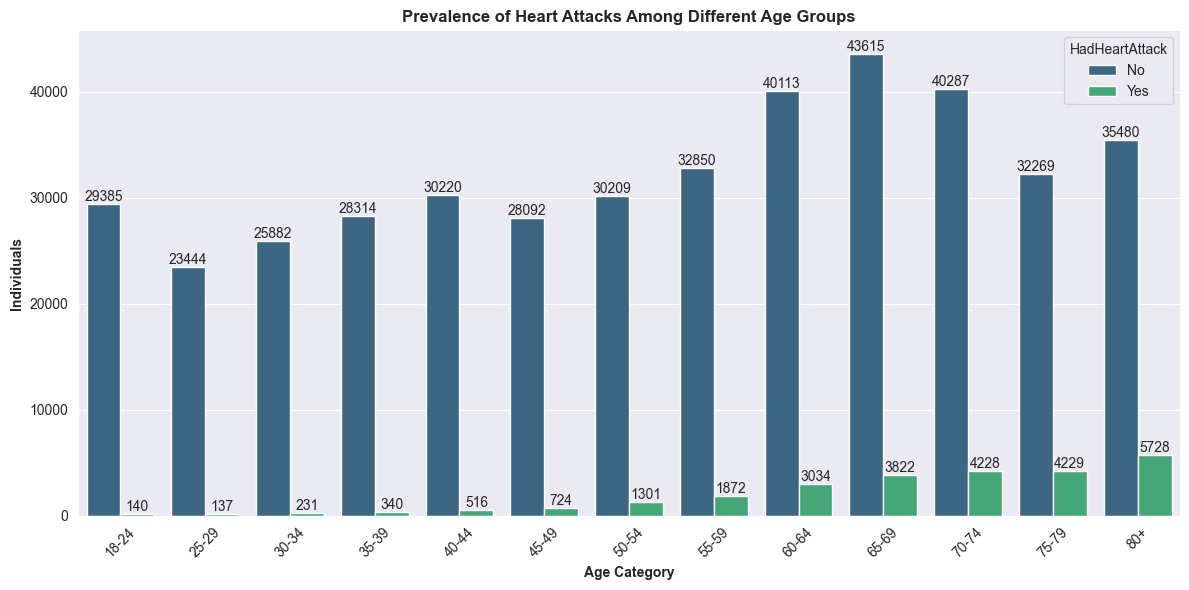

In [8]:
# Make a copy for EDA so we do not mess up the modeling dataframe
df_eda = df.copy()

# Clean AgeCategory if it is still numeric from BRFSS _AGEG5YR
age_map = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80+",
    14: np.nan
}

df_eda["AgeCategory"] = df_eda["AgeCategory"].replace(age_map)

# Clean HadHeartAttack if it is still numeric
heart_attack_map = {
    1: "Yes",
    2: "No",
    7: np.nan,
    9: np.nan
}

df_eda["HadHeartAttack"] = df_eda["HadHeartAttack"].replace(heart_attack_map)

# Drop rows missing the values needed for this graph
df_eda = df_eda.dropna(subset=["AgeCategory", "HadHeartAttack"])

# Set age order for the x-axis
age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64",
    "65-69", "70-74", "75-79", "80+"
]

df_eda["AgeCategory"] = pd.Categorical(
    df_eda["AgeCategory"],
    categories=age_order,
    ordered=True
)

# Make the graph
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

ax = sns.countplot(
    data=df_eda,
    x="AgeCategory",
    hue="HadHeartAttack",
    order=age_order,
    palette="viridis"
)

ax.set_title(
    "Prevalence of Heart Attacks Among Different Age Groups",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Age Category", fontsize=10, fontweight="bold")
ax.set_ylabel("Individuals", fontsize=10, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

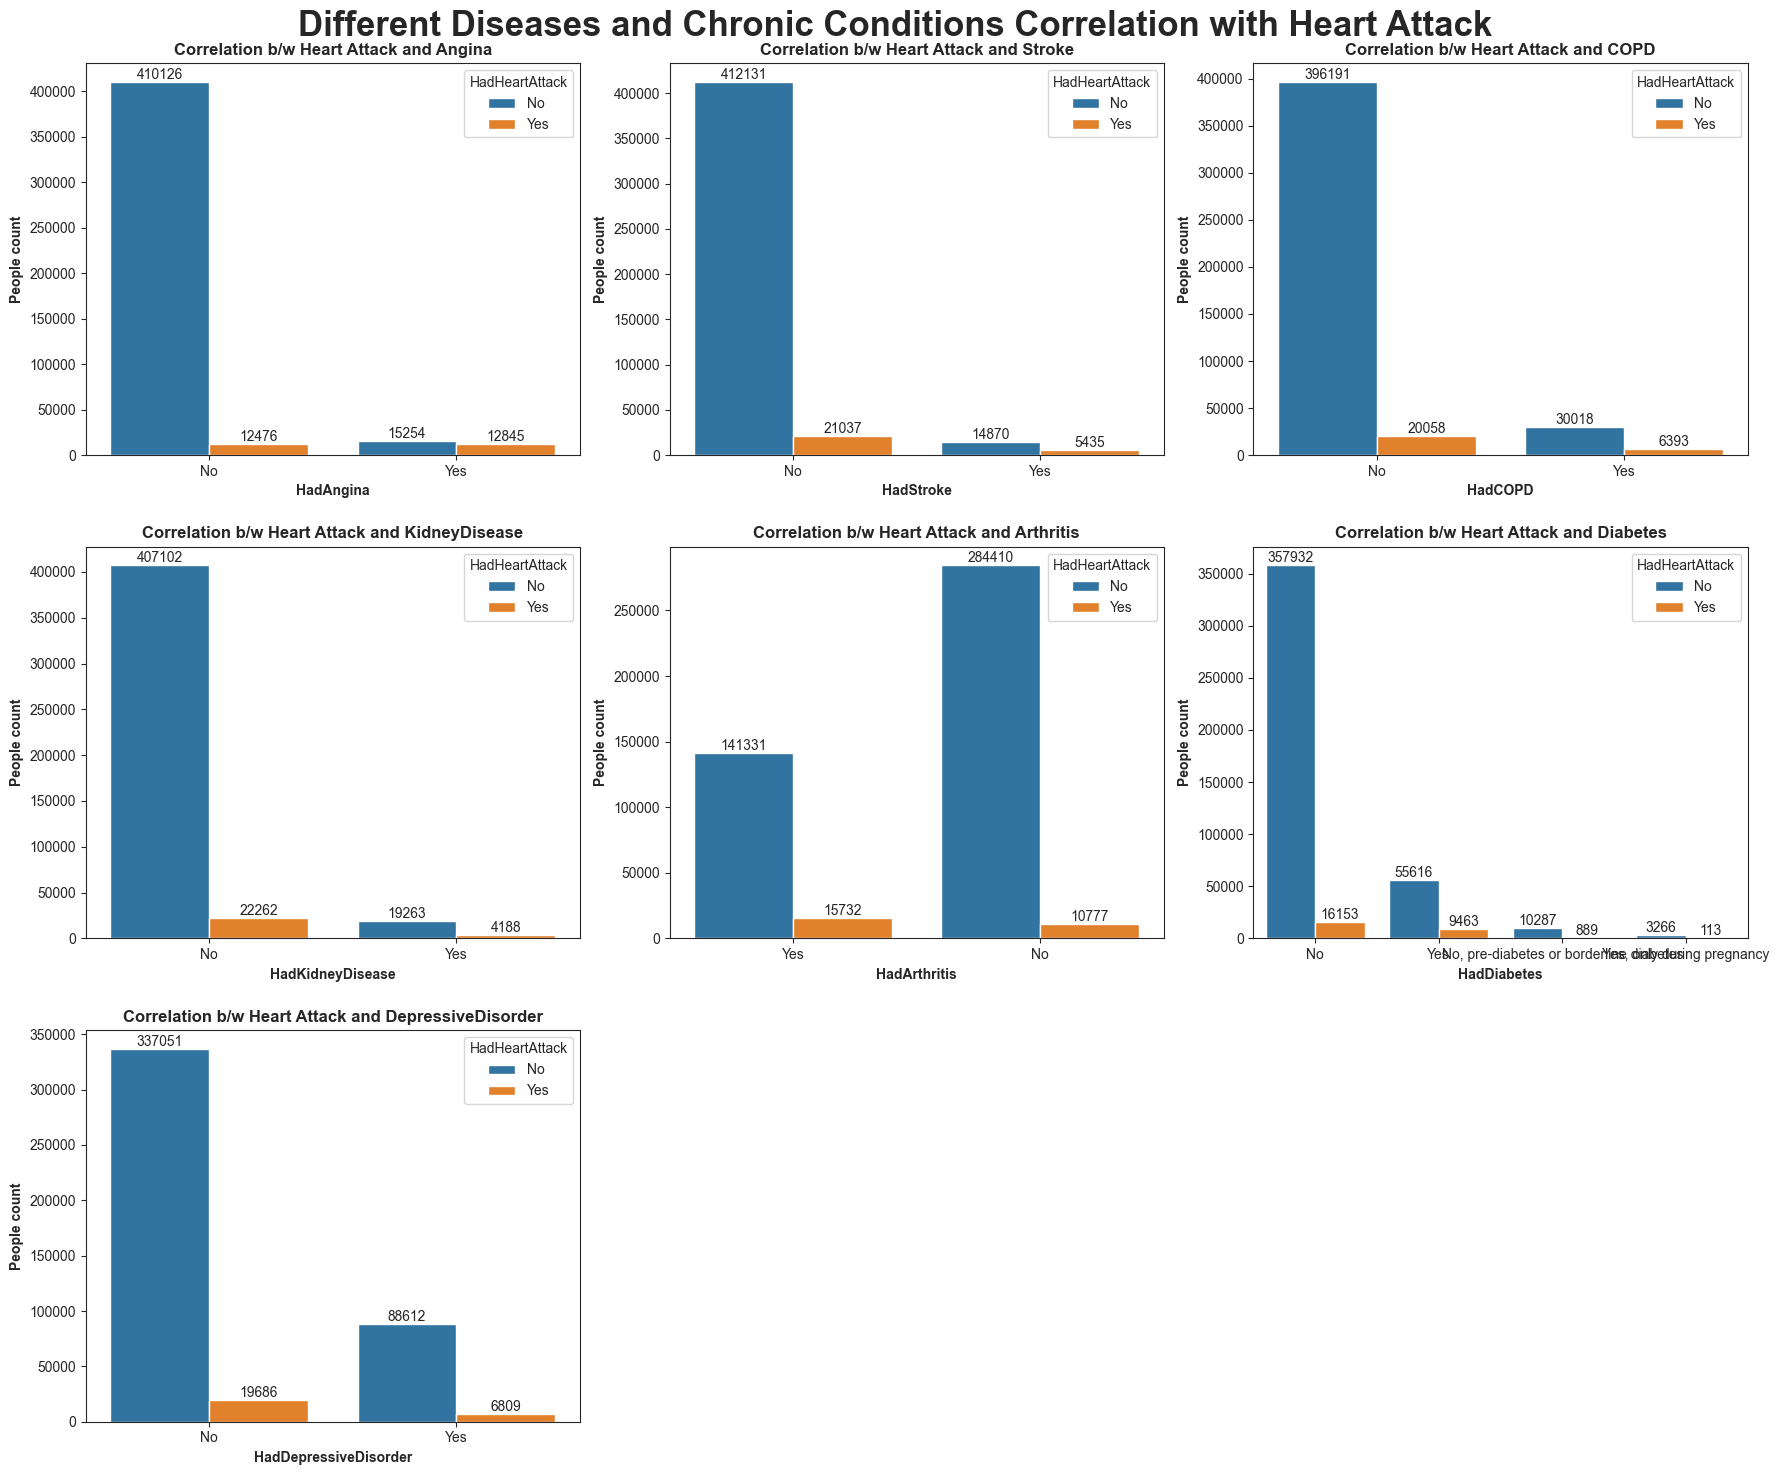

In [11]:
# Chronic condition columns available in the 2024 dataset
chronic_condition_cols = [
    "HadAngina",
    "HadStroke",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "HadDepressiveDisorder"
]

# Clean regular yes/no chronic condition columns
regular_yes_no_cols = [
    "HadAngina",
    "HadStroke",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDepressiveDisorder"
]

for col in regular_yes_no_cols:
    df_eda[col] = df_eda[col].replace(yes_no_map)

# Clean diabetes separately because BRFSS has extra categories
diabetes_map = {
    1: "Yes",
    2: "Yes, only during pregnancy",
    3: "No",
    4: "No, pre-diabetes or borderline diabetes",
    7: np.nan,
    9: np.nan
}

df_eda["HadDiabetes"] = df_eda["HadDiabetes"].replace(diabetes_map)

# Keep only the columns needed for this graph
chronic_diseases = df_eda[
    ["Sex", "HadHeartAttack"] + chronic_condition_cols
].copy()

# Drop rows missing the target
chronic_diseases = chronic_diseases.dropna(subset=["HadHeartAttack"])

# Plot chronic conditions against heart attack status
plt.figure(figsize=(18, 15))
sns.set_style("ticks")

for i, column in enumerate(chronic_condition_cols, 1):
    plt.subplot(3, 3, i)

    plot_data = chronic_diseases.dropna(subset=[column])

    ax = sns.countplot(
        data=plot_data,
        x=column,
        hue="HadHeartAttack"
    )

    clean_title = column.replace("Had", "")

    ax.set_title(
        "Correlation b/w Heart Attack and " + clean_title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(column, fontsize=10, fontweight="bold")
    ax.set_ylabel("People count", fontsize=10, fontweight="bold")

    for container in ax.containers:
        ax.bar_label(container)

plt.suptitle(
    "Different Diseases and Chronic Conditions Correlation with Heart Attack",
    size=25,
    fontweight="bold"
)

plt.tight_layout(w_pad=1, h_pad=2)
plt.show()

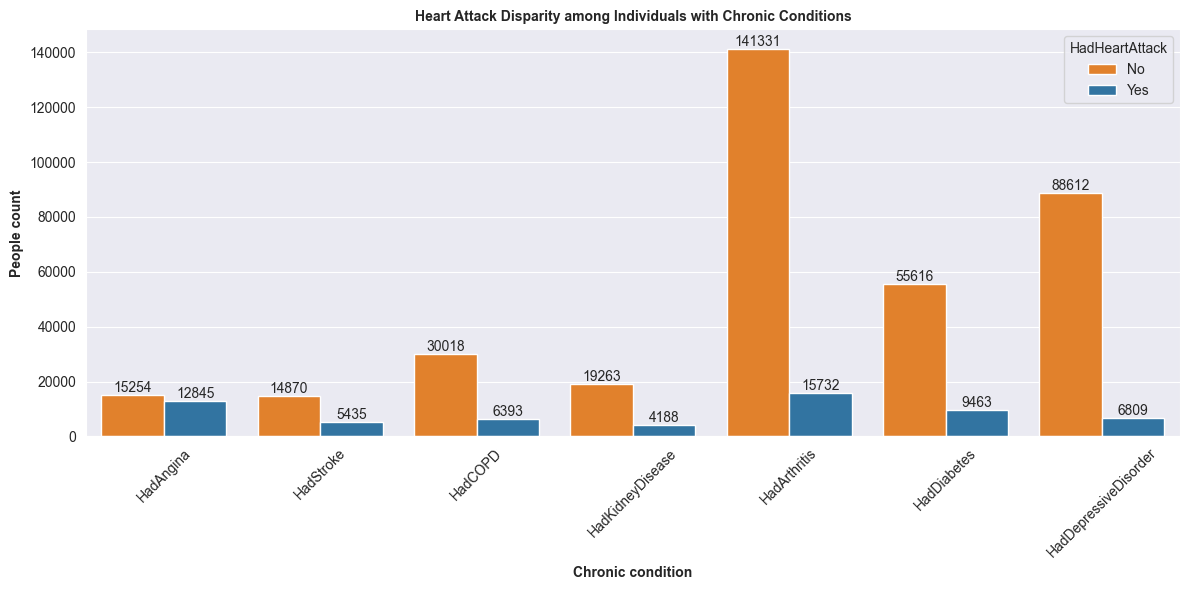

In [12]:
# How does the presence of chronic conditions correlate with heart attack prevalence?

# Make an EDA copy so we do not change the modeling dataframe
df_eda = df.copy()

# Clean HadHeartAttack if it is still numeric
yes_no_map = {
    1: "Yes",
    2: "No",
    7: np.nan,
    9: np.nan
}

df_eda["HadHeartAttack"] = df_eda["HadHeartAttack"].replace(yes_no_map)

# Chronic condition columns available in your current 2024 dataset
chronic_condition_cols = [
    "HadAngina",
    "HadStroke",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "HadDepressiveDisorder"
]

# Clean regular yes/no chronic condition columns
regular_yes_no_cols = [
    "HadAngina",
    "HadStroke",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDepressiveDisorder"
]

for col in regular_yes_no_cols:
    df_eda[col] = df_eda[col].replace(yes_no_map)

# Clean diabetes separately because BRFSS diabetes has extra categories
diabetes_map = {
    1: "Yes",
    2: "Yes, only during pregnancy",
    3: "No",
    4: "No, pre-diabetes or borderline diabetes",
    7: np.nan,
    9: np.nan
}

df_eda["HadDiabetes"] = df_eda["HadDiabetes"].replace(diabetes_map)

# Create chronic_diseases dataframe
chronic_diseases = df_eda[
    ["Sex", "HadHeartAttack"] + chronic_condition_cols
].copy()

# Melt the dataframe so all conditions are in one column
melted_df = chronic_diseases.melt(
    id_vars=["Sex", "HadHeartAttack"],
    value_vars=chronic_condition_cols,
    var_name="Disease",
    value_name="Status"
)

# Select only individuals who have each chronic condition
individuals_with_diseases = melted_df[melted_df["Status"] == "Yes"].copy()

# Plotting bar chart
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")

ax = sns.countplot(
    data=individuals_with_diseases,
    x="Disease",
    hue="HadHeartAttack",
    palette=["tab:orange", "tab:blue"]
)

ax.set_title(
    "Heart Attack Disparity among Individuals with Chronic Conditions",
    fontsize=10,
    fontweight="bold"
)

ax.set_xlabel("Chronic condition", fontsize=10, fontweight="bold")
ax.set_ylabel("People count", fontsize=10, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

HadHeartAttack,No,Yes
Disease,,
HadAngina,15254,12845
HadArthritis,141331,15732
HadCOPD,30018,6393
HadDepressiveDisorder,88612,6809
HadDiabetes,55616,9463
HadKidneyDisease,19263,4188
HadStroke,14870,5435


HadHeartAttack,No,Yes
Disease,,
HadAngina,0.54,0.46
HadArthritis,0.90,0.10
HadCOPD,0.82,0.18
HadDepressiveDisorder,0.93,0.07
HadDiabetes,0.85,0.15
HadKidneyDisease,0.82,0.18
HadStroke,0.73,0.27


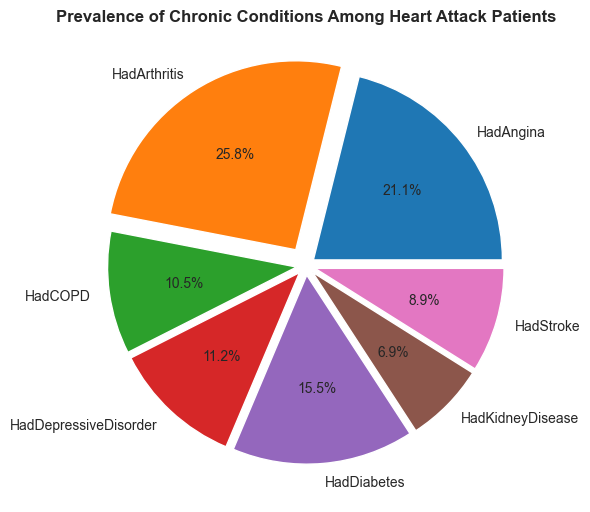

In [13]:
# Create pivot table showing chronic condition counts by heart attack status
pivoted_df = individuals_with_diseases.pivot_table(
    values="Status",
    index="Disease",
    columns="HadHeartAttack",
    aggfunc="count",
    fill_value=0
)

display(pivoted_df)

# Normalize by row to get percentage distribution within each disease
normalized_pivot = round(
    pivoted_df.div(pivoted_df.sum(axis=1), axis=0),
    2
)

display(normalized_pivot)

# Subset only people who had a heart attack
has_heart_attack = pivoted_df["Yes"]

# Make explode list match however many diseases you currently have
explode_values = [0.05] * len(has_heart_attack)

# Emphasize the largest slice
largest_index = has_heart_attack.values.argmax()
explode_values[largest_index] = 0.1

# Plotting pie chart showing share of chronic conditions among people with heart attacks
plt.figure(figsize=(6, 6))

ax = has_heart_attack.plot.pie(
    labels=has_heart_attack.index,
    autopct="%.1f%%",
    explode=explode_values
)

ax.set_title(
    "Prevalence of Chronic Conditions Among Heart Attack Patients",
    fontweight="bold"
)

ax.set_ylabel("")

plt.tight_layout()
plt.show()

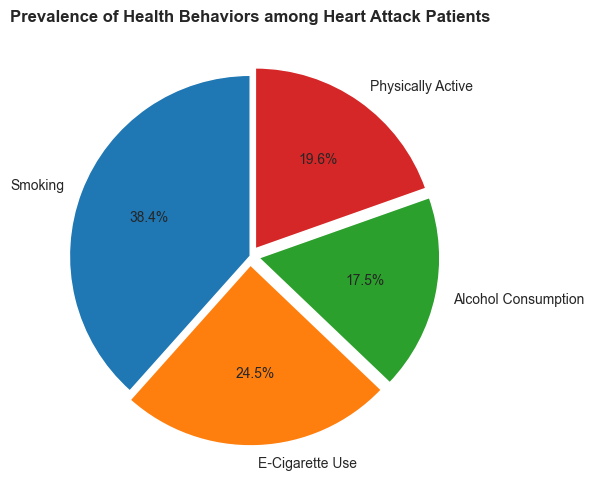

In [15]:
# Make EDA copy
df_eda = df.copy()

yes_no_map = {
    1: "Yes",
    2: "No",
    7: np.nan,
    9: np.nan
}

df_eda["HadHeartAttack"] = df_eda["HadHeartAttack"].replace(yes_no_map)

smoker_status_map = {
    1: "Current smoker - now smokes every day",
    2: "Current smoker - now smokes some days",
    3: "Former smoker",
    4: "Never smoked",
    7: np.nan,
    9: np.nan
}

df_eda["SmokerStatus"] = df_eda["SmokerStatus"].replace(smoker_status_map)

ecigarette_map = {
    1: "Use them every day",
    2: "Use them some days",
    3: "Not at all",
    4: "Never used e-cigarettes",
    7: np.nan,
    9: np.nan
}

df_eda["ECigaretteUsage"] = df_eda["ECigaretteUsage"].replace(ecigarette_map)

if "AlcoholDrinkers" not in df_eda.columns:

    def clean_alcohol_days(value):
        if pd.isna(value):
            return np.nan

        value = int(value)

        if 101 <= value <= 107:
            return (value - 100) * 4
        elif 201 <= value <= 230:
            return value - 200
        elif value == 888:
            return 0
        elif value in [777, 999]:
            return np.nan
        else:
            return np.nan

    df_eda["AlcoholDays"] = df_eda["AlcoholDays"].apply(clean_alcohol_days)

    df_eda["AlcoholDrinkers"] = pd.Series(index=df_eda.index, dtype="object")
    df_eda.loc[df_eda["AlcoholDays"] > 0, "AlcoholDrinkers"] = "Yes"
    df_eda.loc[df_eda["AlcoholDays"] == 0, "AlcoholDrinkers"] = "No"

if "PhysicalActivities" in df_eda.columns:
    df_eda["PhysicalActivities"] = df_eda["PhysicalActivities"].replace(yes_no_map)

SmokerData = df_eda[
    (df_eda["SmokerStatus"] == "Current smoker - now smokes every day") |
    (df_eda["SmokerStatus"] == "Current smoker - now smokes some days")
]

ECigaretteData = df_eda[
    (df_eda["ECigaretteUsage"] == "Use them every day") |
    (df_eda["ECigaretteUsage"] == "Use them some days")
]

AlcoholDrinkersData = df_eda[df_eda["AlcoholDrinkers"] == "Yes"]

behavior_percentages = {
    "Smoking": SmokerData["HadHeartAttack"].value_counts(normalize=True).get("Yes", 0) * 100,
    "E-Cigarette Use": ECigaretteData["HadHeartAttack"].value_counts(normalize=True).get("Yes", 0) * 100,
    "Alcohol Consumption": AlcoholDrinkersData["HadHeartAttack"].value_counts(normalize=True).get("Yes", 0) * 100
}

if "PhysicalActivities" in df_eda.columns:
    PhysicallyActiveData = df_eda[df_eda["PhysicalActivities"] == "Yes"]
    behavior_percentages["Physically Active"] = (
        PhysicallyActiveData["HadHeartAttack"].value_counts(normalize=True).get("Yes", 0) * 100
    )

explode_values = [0.05] * len(behavior_percentages)
explode_values[0] = 0

plt.figure(figsize=(6, 6))

plt.pie(
    behavior_percentages.values(),
    labels=behavior_percentages.keys(),
    autopct="%1.1f%%",
    startangle=90,
    explode=explode_values
)

plt.title(
    "Prevalence of Health Behaviors among Heart Attack Patients",
    weight="bold"
)

plt.tight_layout()
plt.show()

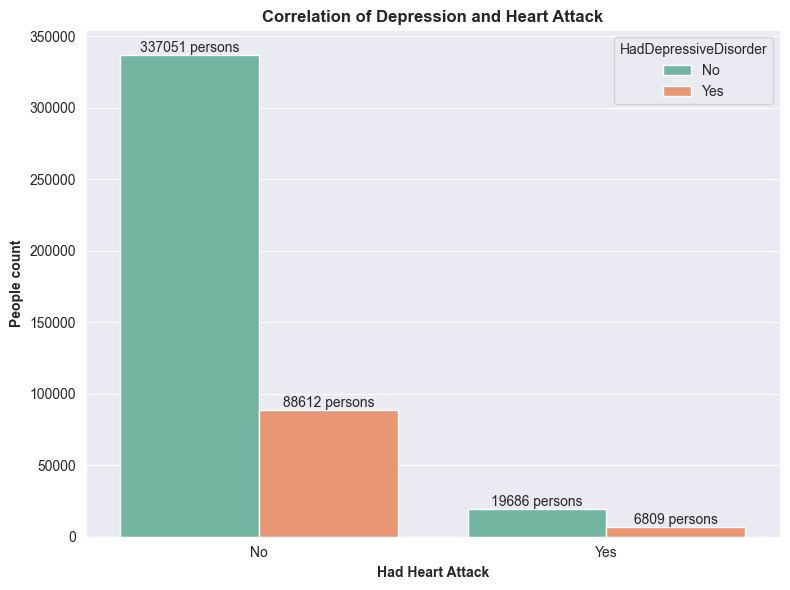

In [16]:
# Effect of mental health on heart

df_eda = df.copy()

# Clean HadHeartAttack if it is still numeric
yes_no_map = {
    1: "Yes",
    2: "No",
    7: np.nan,
    9: np.nan
}

df_eda["HadHeartAttack"] = df_eda["HadHeartAttack"].replace(yes_no_map)

# Clean HadDepressiveDisorder if it is still numeric
df_eda["HadDepressiveDisorder"] = df_eda["HadDepressiveDisorder"].replace(yes_no_map)

# Keep only mental health related columns that exist in your dataset
mental_health_columns = [
    "GeneralHealth",
    "HadHeartAttack",
    "HadDepressiveDisorder"
]

# Add MentalHealthDays only if you kept that column
if "MentalHealthDays" in df_eda.columns:
    mental_health_columns.append("MentalHealthDays")

mental_health_cols = df_eda[mental_health_columns].copy()

# Drop rows missing the values needed for this graph
mental_health_cols = mental_health_cols.dropna(
    subset=["HadHeartAttack", "HadDepressiveDisorder"]
)

# Plot
plt.figure(figsize=(8, 6))
sns.set_style("darkgrid")

ax = sns.countplot(
    data=mental_health_cols,
    x="HadHeartAttack",
    hue="HadDepressiveDisorder",
    palette="Set2"
)

ax.set_title(
    "Correlation of Depression and Heart Attack",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Had Heart Attack", fontsize=10, fontweight="bold")
ax.set_ylabel("People count", fontsize=10, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fmt="%g persons")

plt.tight_layout()
plt.show()

In [17]:
# Function that calculates the percentage of people in each feature category
# who had a heart attack or heart disease

def heart_disease_rate_by_feature(data, feature, target="HadHeartAttack"):
    if feature not in data.columns:
        raise ValueError(f"{feature} is not in the dataframe columns.")

    if target not in data.columns:
        raise ValueError(f"{target} is not in the dataframe columns.")

    temp = data[[feature, target]].copy()

    # Standardize target values so the function works with either:
    # 1/2 coding or Yes/No coding
    target_map = {
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan
    }

    temp[target] = temp[target].replace(target_map)

    # Keep only valid Yes/No target values
    temp = temp[temp[target].isin(["Yes", "No"])]

    # Drop rows where the feature is missing
    temp = temp.dropna(subset=[feature])

    summary = (
        temp
        .groupby(feature)
        .agg(
            total_people=(target, "count"),
            heart_disease_cases=(target, lambda x: (x == "Yes").sum())
        )
        .reset_index()
    )

    summary["heart_disease_percent"] = (
        summary["heart_disease_cases"] / summary["total_people"] * 100
    ).round(2)

    summary = summary.rename(columns={feature: "feature_value"})

    summary.insert(0, "feature", feature)

    summary = summary.sort_values(
        "heart_disease_percent",
        ascending=False
    )

    return summary

**Variables that would be useful to include:**   
* "Sex"
* "AgeCategory"
* "Education"
* "Income"
* "EmploymentStatus"
* "MaritalStatus"
* "HomeOwnership"  
    <br>
* "GeneralHealth"
* "GoodOrBetterHealth"
* "Height"
* "Weight"  
    <br>
* "Smoked100Cigarettes"
* "SmokerStatus"
* "ECigaretteUsage"
* "SmokelessTobaccoUse"
* "AlcoholDays"
* "AlcoholDrinkers"
* "PhysicalActivities"  
   <br>
* "HadAngina"
* "HadDepressiveDisorder"
* "HadDiabetes"
* "HadKidneyDisease"
* "HadStroke"
* "HadCOPD"
* "HadArthritis"  
    <br>
Want to predict: "HadHeartDisease"

In [18]:
predictors = [
    "Sex",
    "AgeCategory",
    "Education",
    "Income",
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnership",
    "GeneralHealth",
    "GoodOrBetterHealth",
    "LastCheckup",
    "Height",
    "Weight",
    "Smoked100Cigarettes",
    "SmokerStatus",
    "ECigaretteUsage",
    "SmokelessTobaccoUse",
    "AlcoholDays",
    "HadDiabetes",
    "HadKidneyDisease",
    "HadStroke",
    "HadCOPD",
    "HadDepressiveDisorder",
    "HadArthritis"
]

heart_disease_dfs = {}

for predictor in predictors:
    if predictor in df.columns:
        heart_disease_dfs[predictor] = heart_disease_rate_by_feature(
            df,
            predictor,
            target="HadHeartAttack"
        )
    else:
        print(f"Skipping {predictor}: not found in df")

for predictor, result_df in heart_disease_dfs.items():
    print(f"\nResults for {predictor}")
    display(result_df)


Results for Sex


,feature,feature_value,total_people,heart_disease_cases,heart_disease_percent
0,Sex,1.0,215757,16216,7.52
1,Sex,2.0,238798,10456,4.38



Results for AgeCategory


,feature,feature_value,total_people,heart_disease_cases,heart_disease_percent
12,AgeCategory,13.0,41208,5728,13.90
11,AgeCategory,12.0,36498,4229,11.59
10,AgeCategory,11.0,44515,4228,9.50
9,AgeCategory,10.0,47437,3822,8.06
8,AgeCategory,9.0,43147,3034,7.03
7,AgeCategory,8.0,34722,1872,5.39
13,AgeCategory,14.0,8093,370,4.57
6,AgeCategory,7.0,31510,1301,4.13
5,AgeCategory,6.0,28816,724,2.51
4,AgeCategory,5.0,30736,516,1.68



Results for Education


...

,feature,feature_value,total_people,heart_disease_cases,heart_disease_percent
1,HadCOPD,Yes,36411,6393,17.56
0,HadCOPD,No,416249,20058,4.82



Results for HadDepressiveDisorder


,feature,feature_value,total_people,heart_disease_cases,heart_disease_percent
1,HadDepressiveDisorder,Yes,95421,6809,7.14
0,HadDepressiveDisorder,No,356737,19686,5.52



Results for HadArthritis


,feature,feature_value,total_people,heart_disease_cases,heart_disease_percent
1,HadArthritis,Yes,157063,15732,10.02
0,HadArthritis,No,295187,10777,3.65


| Variable idea              | Current column name                         |
| -------------------------- | ------------------------------------------- |
| Having angina pain         | `HadAngina`                                 |
| Having depressive disorder | `HadDepressiveDisorder`                     |
| Smoking                    | `SmokerStatus` and/or `Smoked100Cigarettes` |
| Removed teeth              | `RemovedTeeth`                              |
| Difficult walking          | `DifficultyWalking`                         |
| Age 60+                    | `AgeCategory`                               |
| Having arthritis           | `HadArthritis`                              |
| Having diabetes            | `HadDiabetes`                               |
| Lack of physical activity  | `PhysicalActivities`                        |
